In [1]:
from chipanalysis.utils.file_reader import *
from chipanalysis.utils.maye_video_axio  import *

from pathlib import Path
from aicspylibczi import CziFile
import matplotlib.pyplot as plt
import numpy as np
from chipanalysis.utils.ROI_selector import ROI_selector, ROI_selector_down
from chipanalysis.chip_alignment import align_chip_to_image,get_roi_from_result, ChipGeometry

from PIL import Image
import pandas as pd
import numpy as np
%load_ext autoreload
%autoreload 2

%matplotlib widget

In [2]:
root_path = "/Users/bisot/Documents/PostDoc2/test_data"



fig_path = "/Users/bisot/Documents/PostDoc2/test_data"

czi_name = "ICP16-03.czi"



czi_path = Path(root_path,czi_name)
czi = CziFile(czi_path)

dims = czi.dims
sizes = czi.size

dim_sizes = dict(zip(dims, sizes))
dim_sizes["T"]
pixel_size = get_pixel_sizes_um(czi)
times = get_timestamps_by_T(czi, C=0, Z=0)


.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value


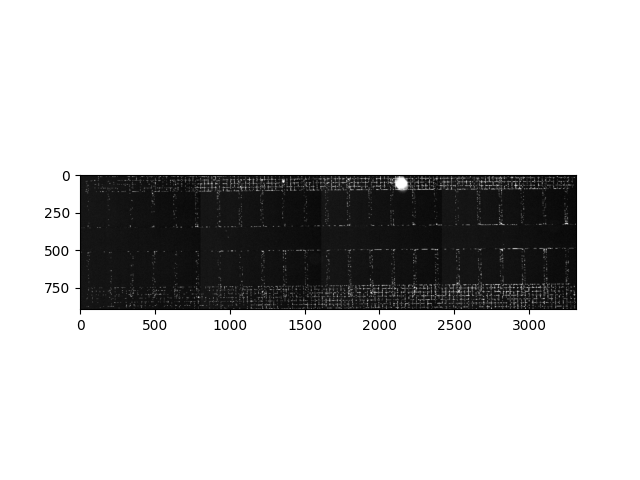

In [15]:
channel = 1
time = 20
scene = 5
img, img_disp = get_frame(czi,time,channel,scene=scene)
fig,ax = plt.subplots()
ax.imshow(img_disp,cmap="gray")

In [19]:
# ── Compute temporal mean image (pixel-wise average across all T frames) ─────
# This captures static background: autofluorescence, uneven illumination, etc.
# Subtracting it from each frame removes anything that doesn't change over time.

n_times = 10
_accum = None
for t in range(n_times):
    raw, _ = get_frame(czi, t, channel, scene=scene)
    frame_f = raw.astype(np.float64)
    _accum = frame_f if _accum is None else _accum + frame_f

temporal_mean = (_accum / n_times).astype(np.float32)
print(f"Temporal mean computed over {n_times} frames  "
      f"(min={temporal_mean.min():.1f}, max={temporal_mean.max():.1f}, "
      f"mean={temporal_mean.mean():.1f})")

Temporal mean computed over 10 frames  (min=57.1, max=2847.0, mean=149.7)


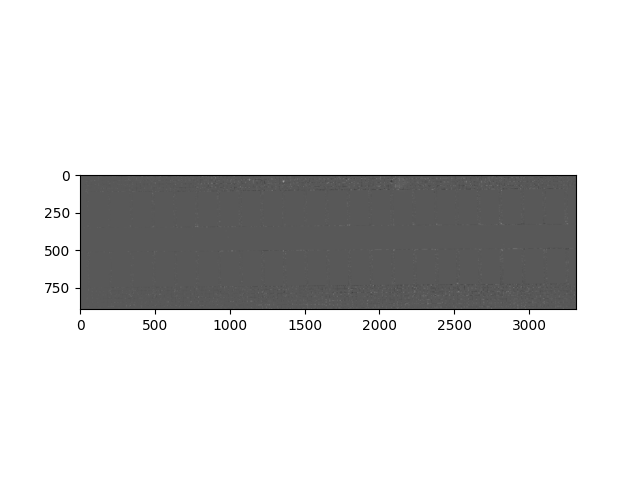

In [20]:
fig,ax = plt.subplots()
ax.imshow(img-temporal_mean,cmap="gray")

/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_83142/252224500.py:42: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=min_obj_px)
/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_83142/252224500.py:43: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller one

ch1 — temporal mean subtraction + Gaussian BG removal + Otsu
  BG σ            : 1000.0 µm  (364.5 px)
  Otsu threshold  : 0.0762  (applied at 0.2×)
  Coverage        : 4.24 %


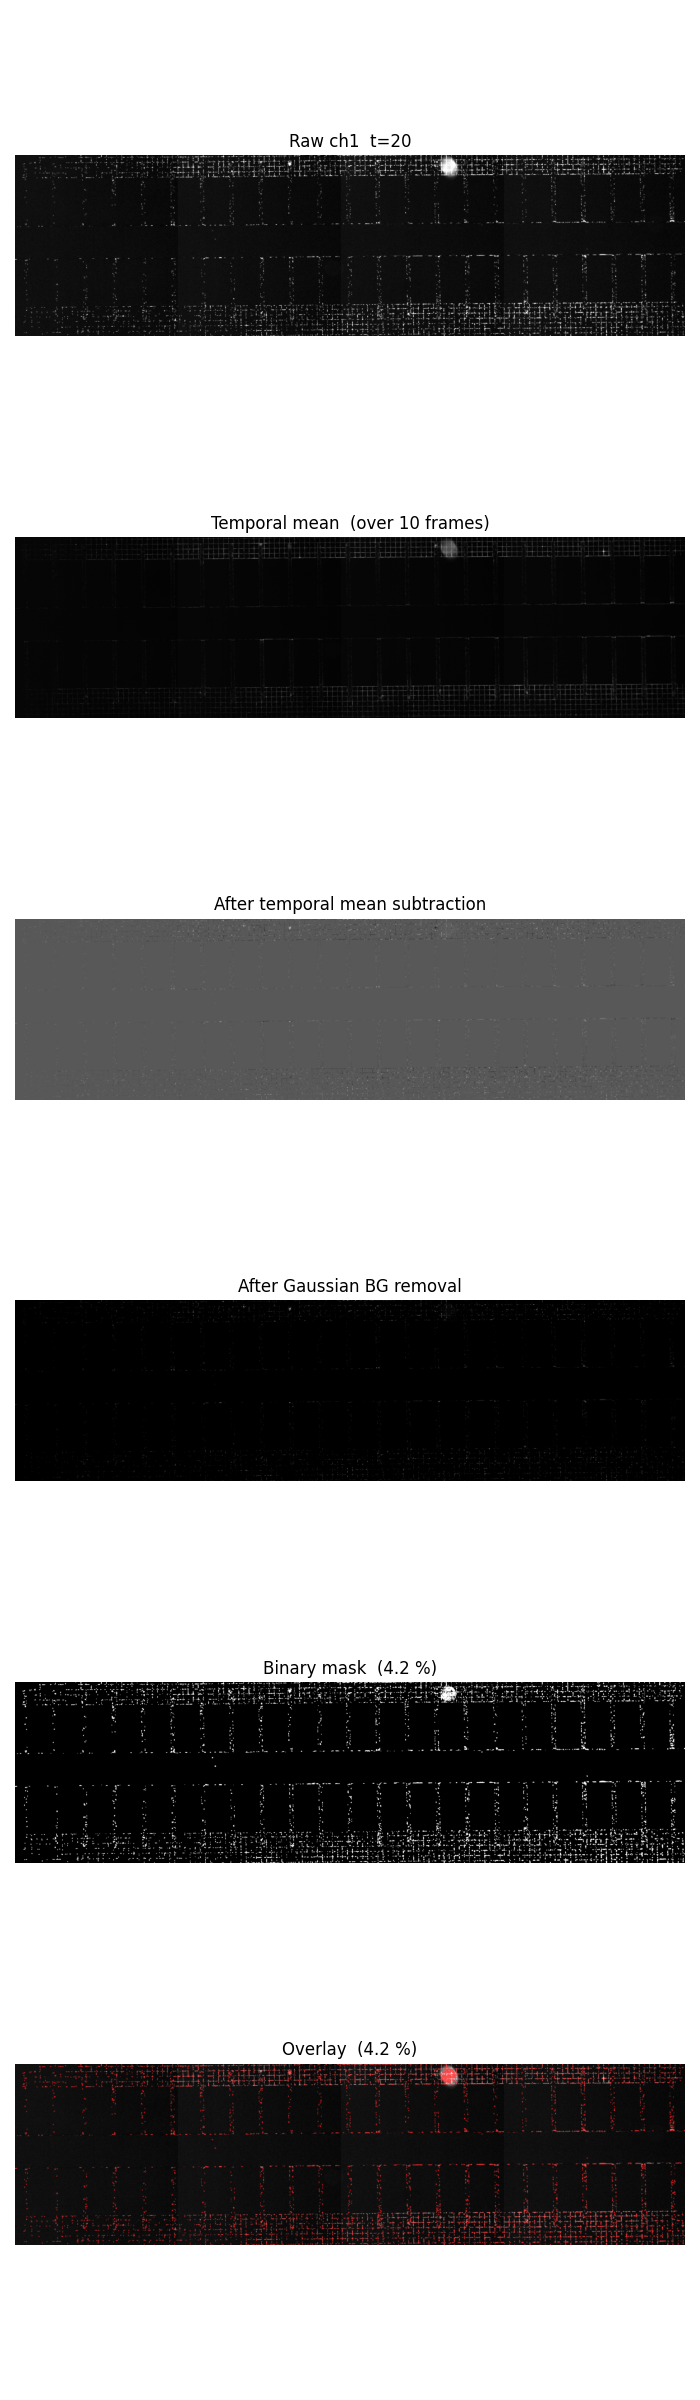

In [22]:
from skimage import exposure
from skimage.filters import gaussian, threshold_otsu
from skimage.morphology import remove_small_objects, remove_small_holes
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ───────────────────────────────────────────────────────────────
channel          = 1
channel_add      = None
time             = 20

BG_SIGMA_UM   = 1000.0   # Gaussian σ for residual spatial gradient removal
MIN_OBJ_UM2   = 25.0
MAX_HOLE_UM2  = 5.0
THRESH_FACTOR = 0.2     # fraction of Otsu threshold

# ── Load frame & normalise ────────────────────────────────────────────────────
px_um = pixel_size["X"]
img_raw, img_disp = get_frame(czi, time, channel, scene=scene, gamma=1,
                               stretch_min=1, stretch_max=99.5)
img_norm = exposure.rescale_intensity(img_raw.astype(np.float32),
                                       out_range=(0.0, 1.0))
H, W = img_norm.shape

# ── Step 1: subtract temporal mean (pixel-wise average across all T) ─────────
img_tempsub = img_raw - temporal_mean
img_tempsub = exposure.rescale_intensity(img_tempsub, out_range=(0.0, 1.0))

# ── Step 2: Gaussian background removal (residual spatial gradients) ──────────
bg_sigma_px = BG_SIGMA_UM / px_um
background  = gaussian(img_tempsub, sigma=bg_sigma_px, preserve_range=True)
bg_removed  = np.clip(img_tempsub - background, 0, None)
bg_removed  = exposure.rescale_intensity(bg_removed, out_range=(0.0, 1.0))

# ── Step 3: Otsu threshold ────────────────────────────────────────────────────
otsu_thresh = threshold_otsu(bg_removed)
binary = bg_removed > THRESH_FACTOR * otsu_thresh

# ── Morphological clean-up ────────────────────────────────────────────────────
min_obj_px  = max(1, int(np.round(MIN_OBJ_UM2  / px_um ** 2)))
max_hole_px = max(1, int(np.round(MAX_HOLE_UM2 / px_um ** 2)))
binary = remove_small_objects(binary, min_size=min_obj_px)
binary = remove_small_holes(binary, area_threshold=max_hole_px)

# ── Measurement ───────────────────────────────────────────────────────────────
pillar_fraction = binary.mean()
ch_label = f"ch{channel}+ch{channel_add}" if channel_add is not None else f"ch{channel}"
print(f"{ch_label} — temporal mean subtraction + Gaussian BG removal + Otsu")
print(f"  BG σ            : {BG_SIGMA_UM:.1f} µm  ({bg_sigma_px:.1f} px)")
print(f"  Otsu threshold  : {otsu_thresh:.4f}  (applied at {THRESH_FACTOR}×)")
print(f"  Coverage        : {pillar_fraction * 100:.2f} %")

# ── Visualisation (single column) ─────────────────────────────────────────────
temporal_mean_disp = exposure.rescale_intensity(temporal_mean.astype(np.float32),
                                                 out_range=(0.0, 1.0))
overlay = np.stack([img_disp, img_disp, img_disp], axis=-1).astype(float)
overlay[binary, 0] = overlay[binary, 0] * 0.3 + 0.7
overlay[binary, 1] = overlay[binary, 1] * 0.3
overlay[binary, 2] = overlay[binary, 2] * 0.3

panels = [
    (img_disp, "gray", f"Raw {ch_label}  t={time}"),
    (temporal_mean_disp, "gray", f"Temporal mean  (over {n_times} frames)"),
    (img_tempsub, "gray", "After temporal mean subtraction"),
    (bg_removed, "gray", "After Gaussian BG removal"),
    (binary, "gray", f"Binary mask  ({pillar_fraction*100:.1f} %)"),
    (np.clip(overlay, 0, 1), None, f"Overlay  ({pillar_fraction*100:.1f} %)"),
]

fig, axes = plt.subplots(len(panels), 1, figsize=(7, 4 * len(panels)))
for ax, (im, cmap, title) in zip(np.atleast_1d(axes), panels):
    if cmap is None:
        ax.imshow(im)
    else:
        ax.imshow(im, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()